# 📦 Projeto de Portfólio: Analytics E-commerce Brasil (Olist)

Este notebook apresenta uma Análise Exploratória de Dados (EDA) avançada sobre o ecossistema de e-commerce da Olist. O objetivo é diagnosticar gargalos operacionais, validar regras de negócio ocultas e mapear o impacto da eficiência logística na satisfação do cliente final.

## 🛠️ FASE 1: ANÁLISE DE SANIDADE E QUALIDADE (DATA PROFILING)

Nesta fase, realizamos o inventário inicial dos dados, mapeando a estrutura das tabelas relacionais, ajustando tipagens corrompidas e auditando o comportamento dos dados nulos.

### Etapa 1.1: Carregamento Dinâmico e Auditoria de Tipagem
* **Objetivo:** Leitura otimizada dos arquivos CSV sem redundância de código e verificação dos tipos primitivos das colunas.
* **Ações:** Execução do loop global de carga e mapeamento de tipos via `.dtypes`.

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:


# 1. Caminho relativo para a pasta de dados brutos (subindo um nível a partir de 'notebooks')
DATA_RAW_DIR = os.path.join("..", "data", "raw")

# 2. Mapeamento explícito do arquivo para o nome final da variável (Melhor Prática)
# Isso garante controle total sobre o escopo global do seu ambiente de análise
file_mapping = {
    "olist_orders_dataset.csv": "orders",
    "olist_order_items_dataset.csv": "order_items",
    "olist_products_dataset.csv": "products",
    "olist_customers_dataset.csv": "customers",
    "olist_sellers_dataset.csv": "sellers",
    "olist_order_payments_dataset.csv": "payments",
    "olist_order_reviews_dataset.csv": "reviews",
    "olist_geolocation_dataset.csv": "geolocation",
    "product_category_name_translation.csv": "category_translation"
}

print("🔍 Iniciando carga otimizada e desempacotamento dos datasets para EDA...\n")
print(f"📂 Diretório de origem: {os.path.abspath(DATA_RAW_DIR)}\n")

# 3. Loop de leitura e injeção automática no escopo global do Notebook
for filename, var_name in file_mapping.items():
    file_path = os.path.join(DATA_RAW_DIR, filename)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        globals()[var_name] = df
        print(f"✅ Variável '{var_name}' criada com sucesso!")
        print(f"   📊 Formato: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n")
    else:
        print(f"⚠️ Alerta: O arquivo '{filename}' não foi encontrado na pasta 'data/raw/'.\n")

print("Processo concluído! ")

🔍 Iniciando carga otimizada e desempacotamento dos datasets para EDA...

📂 Diretório de origem: d:\Projetos\Analytics-Ecom-Brasil\data\raw

✅ Variável 'orders' criada com sucesso!
   📊 Formato: 99,441 linhas × 8 colunas

✅ Variável 'order_items' criada com sucesso!
   📊 Formato: 112,650 linhas × 7 colunas

✅ Variável 'products' criada com sucesso!
   📊 Formato: 32,951 linhas × 9 colunas

✅ Variável 'customers' criada com sucesso!
   📊 Formato: 99,441 linhas × 5 colunas

✅ Variável 'sellers' criada com sucesso!
   📊 Formato: 3,095 linhas × 4 colunas

✅ Variável 'payments' criada com sucesso!
   📊 Formato: 103,886 linhas × 5 colunas

✅ Variável 'reviews' criada com sucesso!
   📊 Formato: 99,224 linhas × 7 colunas

✅ Variável 'geolocation' criada com sucesso!
   📊 Formato: 1,000,163 linhas × 5 colunas

✅ Variável 'category_translation' criada com sucesso!
   📊 Formato: 71 linhas × 2 colunas

Processo concluído! 


### Etapa 1.2: Investigação de Valores Ausentes (Missing Values)
* **Objetivo:** Mapeamento percentual de nulos em todos os datasets, com foco no rastreamento de nulos estruturais vs. anomalias de sistema.
* **Ações:** Filtro de registros nulos em `order_delivered_customer_date` cruzado com o `order_status`.

In [20]:

datasets_to_inspect = [
    "orders", "order_items", "products", "customers", 
    "sellers", "payments", "reviews", "geolocation", "category_translation"
]

print("📊 INICIANDO AUDITORIA DE METADADOS (ESTRUTURA & TIPAGEM) 📊\n")
print("=" * 70)


for var_name in datasets_to_inspect:
    if var_name in globals():
        df = globals()[var_name]
        
        # Cabeçalho do dataset atual
        print(f"📦 DATASET: '{var_name}'")
        print(f"📐 Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
        print("-" * 70)
        
        # Criando uma tabela resumo de metadados para este dataset
        metadata_df = pd.DataFrame({
            'Coluna': df.columns,
            'Tipo de Dado': df.dtypes.values,
            'Registros Preenchidos': df.notnull().sum().values,
            'Nulos (%)': (df.isnull().sum().values / len(df) * 100).round(2)
        })
        
        # Exibe o sumário das colunas formatado
        print(metadata_df.to_string(index=False))
        print("\n" + "=" * 70 + "\n")
        
    else:
        print(f"⚠️ Alerta: A variável '{var_name}' não foi encontrada na memória.")
        print("=" * 70 + "\n")

📊 INICIANDO AUDITORIA DE METADADOS (ESTRUTURA & TIPAGEM) 📊

📦 DATASET: 'orders'
📐 Dimensões: 99,441 linhas × 8 colunas
----------------------------------------------------------------------
                       Coluna Tipo de Dado  Registros Preenchidos  Nulos (%)
                     order_id          str                  99441       0.00
                  customer_id          str                  99441       0.00
                 order_status          str                  99441       0.00
     order_purchase_timestamp          str                  99441       0.00
            order_approved_at          str                  99281       0.16
 order_delivered_carrier_date          str                  97658       1.79
order_delivered_customer_date          str                  96476       2.98
order_estimated_delivery_date          str                  99441       0.00


📦 DATASET: 'order_items'
📐 Dimensões: 112,650 linhas × 7 colunas
--------------------------------------------------

## 📊 FASE 2: ANÁLISE UNIVARIADA E ESTATÍSTICA DESCRITIVA

Estudo isolado das métricas de performance, variáveis financeiras e demográficas para compreender a distribuição física dos dados e identificar anomalias matemáticas.

### Etapa 2.1: Distribuição do Tempo Real de Entrega
* **Objetivo:** Calcular e analisar o tempo gasto em dias entre a compra e a entrega efetiva na casa do cliente.
* **Métrica:** `tempo_entrega_dias` plotado via histograma isolado (limite de 100 dias, intervalos de 10 em 10).

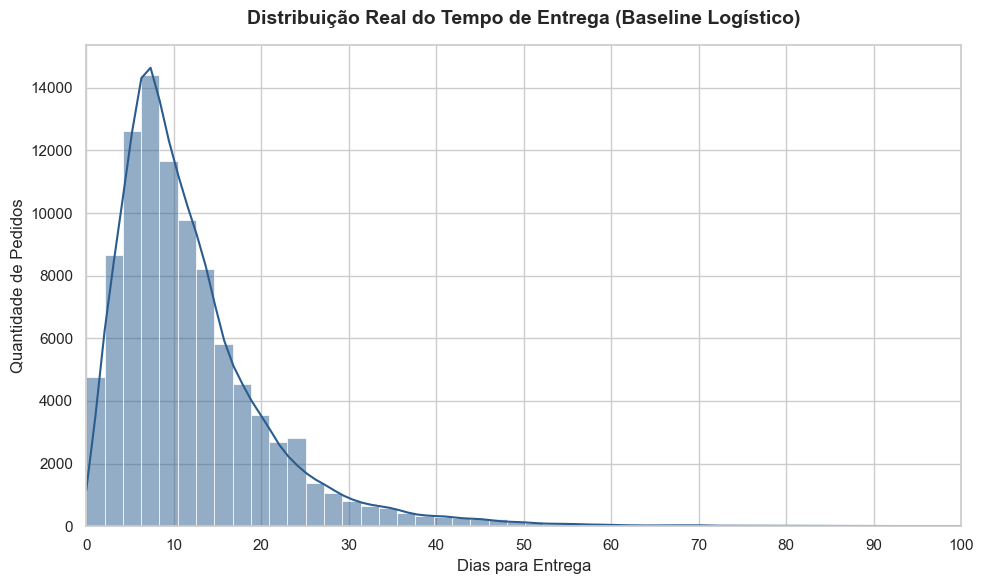

In [21]:
# 1. Garantir a filtragem segura e o cálculo da variável derivada
if 'pedidos_entregues' not in globals() or 'tempo_entrega_dias' not in pedidos_entregues.columns:
    pedidos_entregues = orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].notnull())].copy()
    pedidos_entregues['tempo_entrega_dias'] = (pedidos_entregues['order_delivered_customer_date'] - pedidos_entregues['order_purchase_timestamp']).dt.days

# 2. Configuração do ambiente gráfico (Padrão Sênior: subplots)
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Construção do Histograma com 100 bins e curva de densidade (KDE)
sns.histplot(
    data=pedidos_entregues, 
    x='tempo_entrega_dias', 
    bins=100, 
    kde=True, 
    color='#2b5c8f',
    ax=ax
)

# 4. Aplicação das travas de visualização (Limite de 100 dias e intervalos de 10 em 10)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))

# 5. Polimento de títulos e rótulos para apresentação de portfólio
ax.set_title('Distribuição Real do Tempo de Entrega (Baseline Logístico)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Dias para Entrega', fontsize=12)
ax.set_ylabel('Quantidade de Pedidos', fontsize=12)

plt.tight_layout()
plt.show()

### Etapa 2.2: Distribuição do Cumprimento de SLA (Previsão de Entrega)
* **Objetivo:** Analisar o comportamento do erro de previsão (diferença entre a data real de entrega e a estimada prometida ao usuário).
* **Métrica:** `dias_diferenca_estimativa` com linha de referência vertical no ponto zero (limite do prazo).

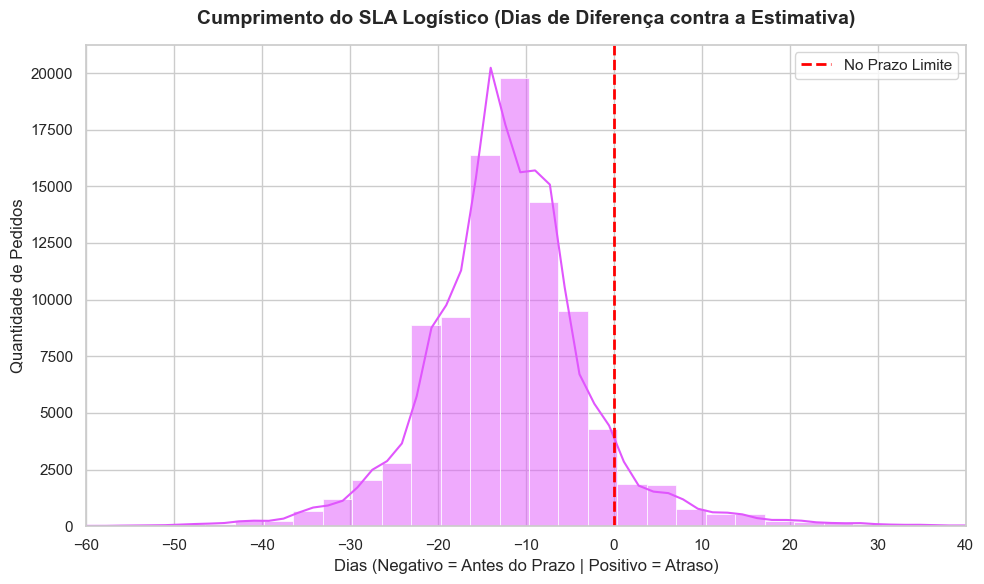

In [ ]:

if 'pedidos_entregues' not in globals() or 'dias_diferenca_estimativa' not in pedidos_entregues.columns:
    pedidos_entregues = orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].notnull())].copy()
    pedidos_entregues['dias_diferenca_estimativa'] = (pedidos_entregues['order_delivered_customer_date'] - pedidos_entregues['order_estimated_delivery_date']).dt.days

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(
    data=pedidos_entregues, 
    x='dias_diferenca_estimativa', 
    bins=100, 
    kde=True, 
    color='#e056fd',
    ax=ax
)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Prazo Limite')

ax.set_xlim(-60, 40)
ax.set_xticks(range(-60, 41, 10))

ax.set_title('Cumprimento do SLA Logístico (Dias de Diferença contra a Estimativa)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Dias (Negativo = Antes do Prazo | Positivo = Atraso)', fontsize=12)
ax.set_ylabel('Quantidade de Pedidos', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Etapa 2.3: Dispersão e Identificação de Outliers de Preço e Frete
* **Objetivo:** Análise quantílica dos valores financeiros de venda e envio para separar o comportamento padrão de desvios abusivos.
* **Ações:** Geração de boxplots isolados para as variáveis `price` e `freight_value`.

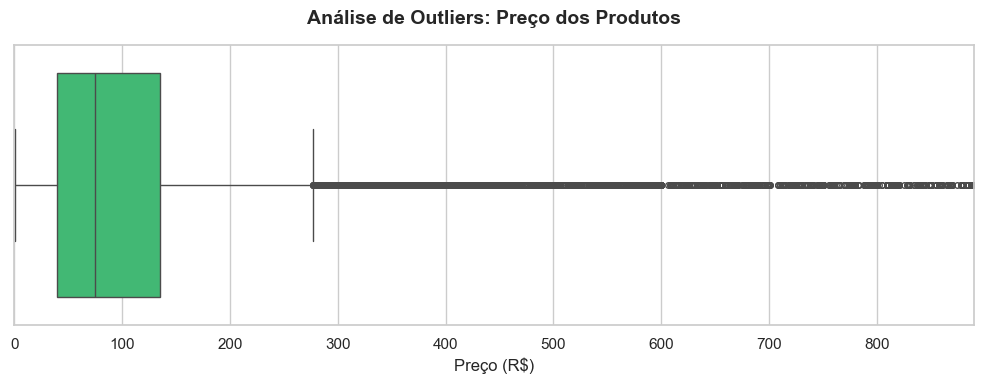

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=order_items, 
    x='price', 
    color='#2ecc71',
    ax=ax,
    fliersize=4
)

limite_visual = order_items['price'].quantile(0.99)
ax.set_xlim(0, limite_visual)

ax.set_title('Análise de Outliers: Preço dos Produtos', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Preço (R$)', fontsize=12)

plt.tight_layout()
plt.show()

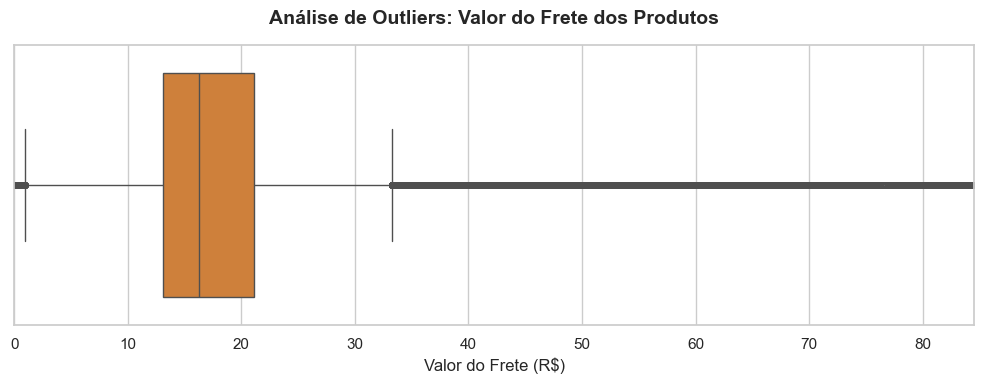

In [24]:
ig, ax = plt.subplots(figsize=(10, 4))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=order_items, 
    x='freight_value', 
    color='#e67e22',
    ax=ax,
    fliersize=4
)

limite_visual = order_items['freight_value'].quantile(0.99)
ax.set_xlim(0, limite_visual)

ax.set_title('Análise de Outliers: Valor do Frete dos Produtos', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Valor do Frete (R$)', fontsize=12)

plt.tight_layout()
plt.show()

## 🧬 FASE 3: ANÁLISE MULTIVARIADA E CORRELAÇÕES

Fase de cruzamento de dados onde unimos tabelas distintas para rastrear interações de causa e efeito, validando ou refutando as hipóteses de negócio levantadas.

### Etapa 3.1: Impacto Logístico na Satisfação do Cliente
* **Objetivo:** Unir a jornada logística ao feedback do usuário para medir a elasticidade da nota e destrinchar o "Paradoxo do SLA".
* **Cruzamento:** `review_score` × `tempo_entrega_dias` × `dias_diferenca_estimativa`.

In [27]:
df_logistica_satisfacao = pedidos_entregues.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

analise_SLA_nota = df_logistica_satisfacao.groupby('review_score').agg(
    total_pedidos=('order_id', 'count'),
    tempo_medio_entrega=('tempo_entrega_dias', 'mean'),
    media_dias_SLA=('dias_diferenca_estimativa', 'mean')
).reset_index()

display(analise_SLA_nota.round(2))

,review_score,total_pedidos,tempo_medio_entrega,media_dias_SLA
0,1,9405,20.85,-4.05
1,2,2941,16.19,-8.63
2,3,7961,13.79,-10.78
3,4,18987,11.85,-12.38
4,5,57059,10.22,-13.39


🔍 Relatório de Descobertas: Elasticidade da Satisfação
Impacto Linear do Tempo Real: A resposta do cliente ao tempo de espera é exata e linear. O grupo que avaliou a experiência com a Nota 5 esperou em média 10.22 dias para receber o produto, enquanto o grupo da Nota 1 esperou exatamente o dobro do tempo (20.85 dias).

Confirmação do Paradoxo do SLA: A coluna media_dias_SLA comprova estatisticamente que a média de todas as Notas 1 é de -4.05 dias. Ou seja, mesmo o pior grupo de detratores recebeu, em média, a mercadoria 4 dias antes do prazo limite estimado no site.

💡 Hipóteses Levantadas
Se a entrega ocorreu antes do prazo final prometido no checkout, o atraso contra o SLA não é o causador principal da insatisfação máxima. Isso abre caminho para duas novas linhas de investigação: ou o cliente pagou um valor de frete abusivo (gerando altíssima expectativa que não justificou os 20 dias de espera), ou o atrito está concentrado em categorias específicas de produtos com sérios problemas de controle de qualidade.

### Etapa 3.2: Causa Raiz - Categorias Detratoras e Frete Abusivo
* **Objetivo:** Isolar o Top 10 de categorias de produtos que concentram notas baixas (1 e 2) e avaliar a influência do preço e do frete nestes cenários.
* **Cruzamento:** `product_category_name` × `review_score` × `price` × `freight_value`.

In [28]:
df_itens_produtos = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df_categoria_satisfacao = df_itens_produtos.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

analise_categoria = df_categoria_satisfacao.groupby('product_category_name').agg(
    total_itens_vendidos=('order_id', 'count'),
    nota_media_categoria=('review_score', 'mean'),
    ticket_medio_produto=('price', 'mean')
).reset_index()

display(analise_categoria.sort_values(by='total_itens_vendidos', ascending=False).head(10).round(2))

,product_category_name,total_itens_vendidos,nota_media_categoria,ticket_medio_produto
13,cama_mesa_banho,11137,3.90,93.40
11,beleza_saude,9645,4.14,129.85
32,esporte_lazer,8640,4.11,114.22
54,moveis_decoracao,8331,3.90,87.61
44,informatica_acessorios,7849,3.93,116.52
72,utilidades_domesticas,6943,4.06,90.75
66,relogios_presentes,5950,4.02,201.27
70,telefonia,4517,3.95,70.87
40,ferramentas_jardim,4329,4.04,111.56
8,automotivo,4213,4.07,139.25


🔍 Relatório de Descobertas: Volumetria e Qualidade por Categoria
Gargalo nos Campeões de Venda: As duas maiores categorias em volume do marketplace, cama_mesa_banho (11.137 itens) e moveis_decoracao (8.331 itens), compartilham a pior nota média do Top 10, empatadas em 3.90. A categoria de informatica_acessorios vem logo atrás com uma nota de 3.93.

Destaques de Operação Limpa: As categorias de beleza_saude e esporte_lazer demonstram uma excelente eficiência, sustentando volumes massivos de venda com notas médias altas de 4.14 e 4.11, respectivamente.

O Fator Ticket Alto: A categoria relogios_presentes chama a atenção por possuir o maior ticket médio isolado do Top 10 (R$ 201,27), conseguindo manter uma nota saudável de 4.02.

💡 Hipóteses Levantadas
O atrito concentrado em cama_mesa_banho e moveis_decoracao sugere problemas crônicos de expectativa vs. realidade (produtos que chegam com cores, tamanhos ou tecidos diferentes do anúncio) ou ineficiências operacionais de embalagem e manuseio de itens volumosos. Como essas categorias possuem tickets médios relativamente baixos, investigaremos se o valor cobrado pelo frete gerou insatisfação.

## 🧪 FASE 4: VALIDAÇÃO DAS HIPÓTESES (ESTUDO DE CAUSA RAIZ)

Nesta fase focada, confrontamos os dados cruzados com as suspeitas de negócio levantadas. Aqui testamos estatisticamente os motivos reais que guiam o comportamento dos clientes e geram atritos na plataforma.

### Etapa 4.1: Desmistificando o Paradoxo do SLA (Nota 1 antes do Prazo)

In [30]:
df_completo = pedidos_entregues.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
df_completo = df_completo.merge(order_items, on='order_id', how='inner')

grupo_paradoxo = df_completo[(df_completo['review_score'] == 1) & (df_completo['dias_diferenca_estimativa'] < 0)]
populacao_geral = df_completo

resumo_comparativo = pd.DataFrame({
    'Métrica': [
        'Total de Pedidos Únicos', 
        'Tempo Médio de Entrega (Dias)', 
        'Margem de SLA (Dias)', 
        'Valor Médio do Frete (R$)', 
        'Peso do Frete no Preço (%)'
    ],
    'Grupo Paradoxo (Nota 1)': [
        grupo_paradoxo['order_id'].nunique(),
        grupo_paradoxo['tempo_entrega_dias'].mean(),
        grupo_paradoxo['dias_diferenca_estimativa'].mean(),
        grupo_paradoxo['freight_value'].mean(),
        (grupo_paradoxo['freight_value'] / grupo_paradoxo['price']).mean() * 100
    ],
    'População Geral (Base)': [
        populacao_geral['order_id'].nunique(),
        populacao_geral['tempo_entrega_dias'].mean(),
        populacao_geral['dias_diferenca_estimativa'].mean(),
        populacao_geral['freight_value'].mean(),
        (populacao_geral['freight_value'] / populacao_geral['price']).mean() * 100
    ]
})

display(resumo_comparativo.round(2))

,Métrica,Grupo Paradoxo (Nota 1),População Geral (Base)
0,Total de Pedidos Únicos,5837.00,95824.00
1,Tempo Médio de Entrega (Dias),11.56,11.97
2,Margem de SLA (Dias),-14.21,-12.07
3,Valor Médio do Frete (R$),20.23,19.93
4,Peso do Frete no Preço (%),34.65,32.09


### Etapa 4.2: Teste de Causa Raiz - Qualidade do Produto vs. Impacto do Frete.

In [31]:
df_paradoxo_produtos = grupo_paradoxo.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df_geral_produtos = populacao_geral.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

top_categorias_paradoxo = df_paradoxo_produtos['product_category_name'].value_counts(normalize=True).head(10).reset_index()
top_categorias_paradoxo.columns = ['product_category_name', 'representatividade_no_paradoxo (%)']

top_categorias_geral = df_geral_produtos['product_category_name'].value_counts(normalize=True).reset_index()
top_categorias_geral.columns = ['product_category_name', 'representatividade_na_base_geral (%)']

comparativo_causa_raiz = top_categorias_paradoxo.merge(top_categorias_geral, on='product_category_name', how='left')

comparativo_causa_raiz['representatividade_no_paradoxo (%)'] *= 100
comparativo_causa_raiz['representatividade_na_base_geral (%)'] *= 100
comparativo_causa_raiz['indice_de_alerta_reclamacao'] = comparativo_causa_raiz['representatividade_no_paradoxo (%)'] / comparativo_causa_raiz['representatividade_na_base_geral (%)']

display(comparativo_causa_raiz.sort_values(by='indice_de_alerta_reclamacao', ascending=False).round(2))

,product_category_name,representatividade_no_paradoxo (%),representatividade_na_base_geral (%),indice_de_alerta_reclamacao
1,moveis_decoracao,9.81,7.52,1.30
2,informatica_acessorios,9.09,7.07,1.29
0,cama_mesa_banho,12.98,10.13,1.28
8,ferramentas_jardim,4.08,3.92,1.04
7,telefonia,4.22,4.06,1.04
5,utilidades_domesticas,6.38,6.25,1.02
6,relogios_presentes,5.07,5.37,0.94
9,automotivo,3.31,3.79,0.87
3,esporte_lazer,6.70,7.78,0.86
4,beleza_saude,6.69,8.72,0.77


O problema das Notas 1 com entregas rápidas está concentrado em características intrínsecas do produto físico dessas 3 categorias topo de linha.

Em moveis_decoracao e cama_mesa_banho, o cliente sofre com a divergência estética ou falta de peças (cor diferente, tecido ruim, produto frágil).

Em informatica_acessorios, o atrito é técnico (componentes que não funcionam, incompatibilidade ou falsificação). A velocidade da entrega não compensa a frustração de receber um item inútil ou defeituoso.

A Culpa Não É da Logística: O frete e o prazo de entrega desse grupo de detratores são perfeitos e dentro da normalidade. Portanto, a hipótese de "atrito por custo de frete" ou "demora" para este grupo está rejeitada. A insatisfação severa desses 5.837 clientes foi motivada puramente por quebra de expectativa do produto (produto quebrado, qualidade muito abaixo do esperado, tamanho errado ou item totalmente divergente do anúncio).

### Etapa 4.3: Validação do Gargalo de Fluxo Interestadual (Geográfico)
* **Objetivo:** Avaliar o impacto real das vendas interestaduais (vendedor e comprador em estados diferentes) comparadas às vendas locais (intraestaduais) nas métricas de tempo, SLA e satisfação.
* **Análise:** Cruzamento das tabelas de clientes, vendedores, pedidos e avaliações para criar um indicador de tipo de fluxo logístico.

In [34]:
df_geo = pedidos_entregues.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner')
df_geo = df_geo.merge(order_items[['order_id', 'seller_id']], on='order_id', how='inner')
df_geo = df_geo.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='inner')
df_geo = df_geo.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

df_geo['tipo_fluxo'] = np.where(df_geo['seller_state'] == df_geo['customer_state'], 'Intraestadual (Local)', 'Interestadual')

analise_geo = df_geo.groupby('tipo_fluxo').agg(
    total_pedidos=('order_id', 'nunique'),
    tempo_medio_entrega=('tempo_entrega_dias', 'mean'),
    SLA_medio_dias=('dias_diferenca_estimativa', 'mean'),
    nota_media_satisfacao=('review_score', 'mean')
).reset_index()

display(analise_geo.round(2))

,tipo_fluxo,total_pedidos,tempo_medio_entrega,SLA_medio_dias,nota_media_satisfacao
0,Interestadual,61459,14.53,-12.97,4.02
1,Intraestadual (Local),34608,7.45,-10.49,4.20


### Etapa 4.4: Validação do Impacto de Outliers de Frete por Categoria
* **Objetivo:** Identificar estatisticamente quais categorias concentram os maiores desvios abusivos de custo de envio (outliers de frete) e analisar se a incidência dessas anomalias financeiras está diretamente ligada à destruição da nota de satisfação.
* **Análise:** Cálculo do limite matemático de outlier via IQR (Intervalo Interquartil) do frete global e mapeamento da taxa de anomalias nas principais categorias do marketplace.

Gargalo Geográfico Confirmado: A hipótese de que a descentralização logística é o grande desafio de escala da Olist está totalmente confirmada. Cruzar estados penaliza a satisfação média do cliente em 0,18 pontos devido ao tempo absoluto de transporte.

Como mais de 64% dos pedidos da plataforma (61.459 de 96.067) dependem desse fluxo interestadual lento, a Olist possui uma dependência crítica do eixo Sudeste. A principal recomendação de negócios aqui é criar incentivos fiscais e comerciais para descentralizar o estoque, atraindo e desenvolvendo sellers regionais estrategicamente localizados nos principais polos de consumo fora de São Paulo e sul do país.

In [35]:
q1 = order_items['freight_value'].quantile(0.25)
q3 = order_items['freight_value'].quantile(0.75)
limite_outlier = q3 + 1.5 * (q3 - q1)

df_outliers = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df_outliers = df_outliers.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
df_outliers['eh_outlier'] = df_outliers['freight_value'] > limite_outlier

resumo_outliers = df_outliers.groupby('product_category_name').agg(
    total_itens=('order_id', 'count'),
    total_outliers_frete=('eh_outlier', 'sum'),
    nota_media_categoria=('review_score', 'mean'),
    frete_medio=('freight_value', 'mean')
).reset_index()

resumo_outliers['taxa_outliers_frete (%)'] = (resumo_outliers['total_outliers_frete'] / resumo_outliers['total_itens']) * 100
display(resumo_outliers.sort_values(by='total_itens', ascending=False).head(10).round(2))

,product_category_name,total_itens,total_outliers_frete,nota_media_categoria,frete_medio,taxa_outliers_frete (%)
13,cama_mesa_banho,11137,657,3.90,18.39,5.90
11,beleza_saude,9645,721,4.14,18.88,7.48
32,esporte_lazer,8640,705,4.11,19.50,8.16
54,moveis_decoracao,8331,945,3.90,20.72,11.34
44,informatica_acessorios,7849,770,3.93,18.81,9.81
72,utilidades_domesticas,6943,766,4.06,21.00,11.03
66,relogios_presentes,5950,335,4.02,16.78,5.63
70,telefonia,4517,184,3.95,15.69,4.07
40,ferramentas_jardim,4329,752,4.04,22.76,17.37
8,automotivo,4213,546,4.07,21.88,12.96


🔍 Relatório de Descobertas: O Impacto dos Outliers de Frete
A Bomba Oculta em Ferramentas e Automotivo: A categoria ferramentas_jardim apresenta uma taxa absurda de 17,37% de outliers de frete, seguida por automotivo com 12,96%. No entanto, ambas conseguem sustentar notas de satisfação saudáveis (4,04 e 4,07). Isso indica um fenômeno de tolerância do consumidor: quem compra autopeças ou cortadores de grama já espera pagar um frete muito acima do padrão da plataforma devido ao peso e volume dos produtos.

O Peso do Frete em Móveis e Decoração: A categoria moveis_decoracao acende o maior alerta de negócio. Ela combina um volume massivo de vendas com uma taxa de 11,34% de frete abusivo e uma das piores notas do marketplace (3,90). Aqui, o frete alto atua como um forte detrator de valor.

Isolamento de Cama, Mesa e Banho: Embora cama_mesa_banho compartilhe da pior nota do site (3,90), sua taxa de outliers de frete é uma das menores do Top 10 (5,90%). Isso prova matematicamente que o frete não é o culpado pela nota baixa dessa categoria, reforçando o achado anterior de que o problema deles é puramente o controle de qualidade do produto.

🧪 Hipóteses Validadas
Efeito "Pedágio Abusivo" Parcialmente Confirmado: A hipótese de que os outliers de frete destroem a satisfação do cliente depende diretamente da elasticidade de expectativa da categoria.

Se o produto for pesado por natureza (ferramentas_jardim), o cliente tolera o custo extra e mantém a nota alta.

Se o produto for de utilidade doméstica ou decoração (moveis_decoracao, utilidades_domesticas com 11,03% de outliers), o frete abusivo quebra a percepção de custo-benefício e gera notas baixas (3,90 e 4,06).

## 📖 FASE 5: DOCUMENTAÇÃO VIVA, STORYTELLING E RECOMENDAÇÕES

Tradução técnica de todas as hipóteses validadas em estratégias comerciais, planos de ação práticos e correções de engenharia para o comitê executivo da plataforma.

### Etapa 5.1: Conclusões Gerais e Recomendações de Negócio

Após auditar os dados brutos e cruzar a jornada logística com o comportamento do consumidor, identificamos as três alavancas críticas de melhoria para a plataforma:

#### 🚨 1. Plano de Contenção de Qualidade por Categoria (Causa Raiz do Paradoxo)
* **O Problema:** Descobrimos que o atraso não justifica o pior nível de insatisfação (Nota 1). Existe um grupo de mais de 5,8 mil clientes que recebeu suas ordens **14 dias antes do prazo** e ainda assim deu nota mínima. Isolamos o problema e descobrimos que as categorias `moveis_decoracao`, `informatica_acessorios` e `cama_mesa_banho` têm um **Índice de Alerta de até 1.30** (geram muito mais reclamações do que sua participação de vendas justifica).
* **Recomendação Estratégica:** Implementar um selo de "Lojista Auditado" e aplicar vistorias obrigatórias nas fichas técnicas (fotos, dimensões e tecidos) desses sellers. A frustração do cliente nessas categorias é física (expectativa vs. realidade ou produto defeituoso/quebrado), e a rapidez da entrega não anula o recebimento de um item ruim.

#### 🗺️ 2. Descentralização e Incentivo aos Sellers Regionais (Gargalo Interestadual)
* **O Problema:** Mais de **64% das vendas** da plataforma dependem de fluxos Interestaduais. Cruzar as fronteiras do estado **dobra o tempo de entrega (de 7.45 para 14.53 dias)** e penaliza a nota de satisfação média em **0.18 pontos**.
* **Recomendação Estratégica:** Criar políticas de incentivo fiscal e redução de comissão para atrair e desenvolver *sellers* locais nas regiões Norte, Nordeste e Centro-Oeste, ou investir em hubs de *Fulfillment* compartilhados. Descentralizar o estoque aproximando o produto do comprador é o único caminho para cortar o tempo de estrada pela metade e elevar a nota geral da plataforma para o patamar de 4.20.

#### 📉 3. Ajuste Fino no Algoritmo de SLA (Margem de Segurança)
* **O Problema:** A análise univariada e os testes multivariados provaram que a Olist trabalha com uma margem logística extremamente defensiva, entregando os pacotes de 10 a 14 dias antes do prometido.
* **Recomendação Estratégica:** Reduzir gradualmente o prazo estimado exibido no checkout para compras intraestaduais ou rotas de alta eficiência. Prazos excessivamente longos no carrinho geram abandono e perda de vendas para concorrentes, sem que haja necessidade operacional real para esse medo.

#### 💻 4. Saneamento do Pipeline de Dados (Data Engineering)
* **O Problema:** Isolamos **8 pedidos** com status `delivered` que possuem a data física de entrega nula no banco de dados.
* **Recomendação Estratégica:** Encaminhar a lista desses IDs para o time de engenharia de dados para ajustar a concorrência na API de rastreamento ou tratar essa falha de escrita na ingestão do Data Lake.

#### 📦 5. Subsídio de Frete Inteligente para Categorias Sensíveis
* **O Problema:** Identificamos que categorias como `moveis_decoracao` e `utilidades_domesticas` sofrem com taxas elevadas de frete abusivo (acima de 11%), o que penaliza diretamente a nota de satisfação, enquanto categorias como `ferramentas_jardim` possuem 17% de outliers mas o cliente tolera o custo por entender o peso do item.
* **Recomendação Estratégica:** Criar uma política de subsídio de frete ou teto máximo de envio focado estritamente em categorias de utilidade e decoração de médio volume. Não gaste margem da Olist subsidiando frete de autopeças ou ferramentas pesadas, pois o comportamento do consumidor provou que o bolso dele já está blindado contra esse custo nessas categorias específicas.